# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sqpulse import (
    GaussianPulse,
    CosinePulse,
    LorentzianPulse,
    SquarePulse,
    FlatTopPulse,
    DRAGPulse,
    SechPulse,
    SlepianPulse,
    NetZeroPulse,
    CosineHD2DRAGPulse,
    PhaseModulatedSinPulse,
    IdlePulse,
    CustomPulse,
    compare_pulses,
    spectral_leakage,
    Transmon,
    PulseSequence,
    Simulator,
    RabiExperiment,
    T1Experiment,
    RamseyExperiment,
)

from sqpulse.experiments import QubitSpectroscopyExperiment

# 一、脉冲波形与时频域特征分析

In [ ]:
p_gauss = GaussianPulse(duration=40e-9, amp=0.8, chop=6.0, drag=0, name="Gaussian")
fig = p_gauss.plot(domain="both")

In [ ]:
p_cos = CosinePulse(duration=40e-9, amp=1.0, drag=0, detune=0.0, name="Cosine (Hann)")
fig = p_cos.plot(domain="both")

In [ ]:
p_lorentz = LorentzianPulse(duration=40e-9, amp=1.0, gamma=10e-9, name="Lorentzian")
fig = p_lorentz.plot(domain="both")

In [ ]:
p_square = SquarePulse(duration=40e-9, amp=1.0, name="Square")
fig = p_square.plot(domain="both")

In [ ]:
p_flattop = FlatTopPulse(duration=40.0e-9, amp=1.0, ramp_time=4e-9, ramp_type="gaussian", name="FlatTop (Gaussian)")
fig = p_flattop.plot(domain="both")

In [ ]:
p_flattop_os = FlatTopPulse(
    duration=60e-9,
    amp=0.8,
    ramp_time=15e-9,
    ramp_type="tanh",
    # overshoot_amp=0.2,
    # overshoot_len=10e-9,
    name="FlatTop (Tanh+Overshoot)",
)
fig = p_flattop_os.plot(domain="both")

In [ ]:
p_drag = DRAGPulse(duration=40e-9, amp=1.0, drag=1, sigma=8e-9, name="Gaussian+DRAG")
fig = p_drag.plot(domain="both")

In [ ]:
p_hd2 = CosineHD2DRAGPulse(
    duration=20e-9,
    amp=1.0,
    alpha=-250e6,
    f_suppress=90e6,
    name="Cosine HD-DRAG",
)
fig = p_hd2.plot(domain="both")

In [ ]:
p_sech = SechPulse(duration=40e-9, amp=0.8, sigma=10e-9, name="Sech")
fig = p_sech.plot(domain="both")

In [ ]:
p_slepian = SlepianPulse(duration=40e-9, amp=0.8, nw=3.0, name="Slepian (DPSS)")
fig = p_slepian.plot(domain="both")

In [ ]:
p_netzero = NetZeroPulse(duration=60e-9, amp=0.8, ramp_type="erf", name="Net-Zero Flux")
fig = p_netzero.plot(domain="both")

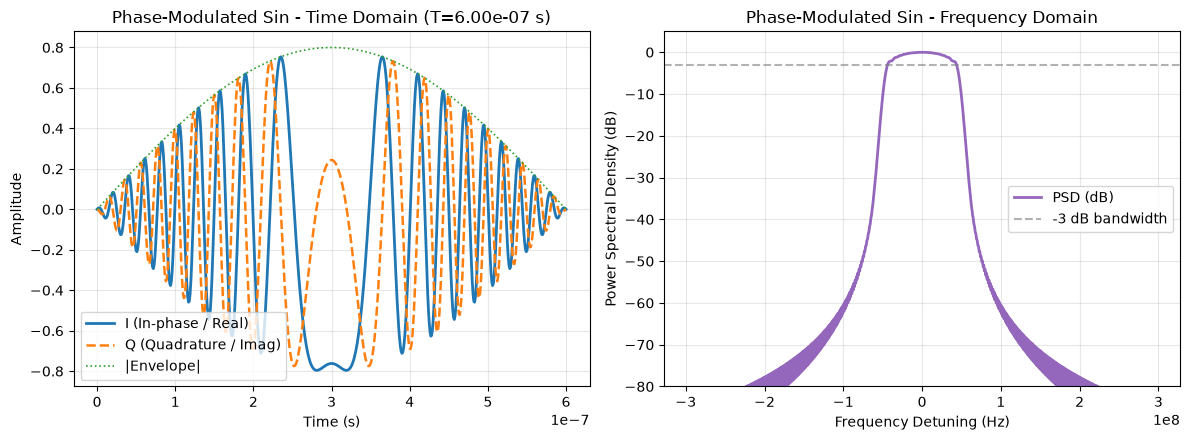

In [8]:
p_pm = PhaseModulatedSinPulse(duration=600e-9, amp=0.8, mod_freq=50e6, name="Phase-Modulated Sin")
fig = p_pm.plot(domain="both")

In [ ]:
p_idle = IdlePulse(duration=40e-9, name="Idle")
fig = p_idle.plot(domain="both")

In [ ]:
p_custom = CustomPulse(
    duration=40e-9,
    envelope_fn=lambda t: np.sin(np.pi * t / 40e-9) ** 4,
    name="Custom (Sin^4)",
)
fig = p_custom.plot(domain="both")

In [ ]:
fig_comp = compare_pulses(
    [p_gauss, p_cos, p_lorentz, p_sech, p_slepian],
    domain="both",
    dt=0.1e-9,
    freq_range=(-300e6, 300e6),
)

In [ ]:
# 计算 100 MHz 外的高频谱泄露比例
cutoff = 100e6
print(f"方波脉冲谱泄露 (>100 MHz):     {spectral_leakage(p_square, cutoff):.6f}")
print(f"洛伦兹脉冲谱泄露 (>100 MHz):   {spectral_leakage(p_lorentz, cutoff):.6f}")
print(f"高斯脉冲谱泄露 (>100 MHz):     {spectral_leakage(p_gauss, cutoff):.6f}")
print(f"余弦脉冲谱泄露 (>100 MHz):     {spectral_leakage(p_cos, cutoff):.6f}")
print(f"Sech脉冲谱泄露 (>100 MHz):     {spectral_leakage(p_sech, cutoff):.6f}")
print(f"Slepian脉冲谱泄露 (>100 MHz):  {spectral_leakage(p_slepian, cutoff):.6f}")

# 二、Transmon 物理模型与演化

## test-1

In [ ]:
transmon = Transmon(
    name="q0",
    f_q=5e9,        # 5.0 GHz
    alpha=-250e6,    # -250 MHz
    levels=3,       # 3 能级 (|0>, |1>, |2>)
    t1=25e-6,     # T1 = 25 us
    t2=4e-6,     # T2 = 18 us
    omega_d=2*np.pi*120e6,
)
print(transmon)

In [ ]:
# 编排序列：一个高斯脉冲驱动 -> 延时 20 ns -> 另一个脉冲
seq = PulseSequence(name="sample_sequence")
seq.add(transmon.drive, GaussianPulse(duration=30e-9, amp=0.5))
seq.delay(transmon.drive, 20e-9)
seq.add(transmon.drive, CosinePulse(duration=30e-9, amp=0.4))

fig_seq = seq.plot(dt=0.1e-9)

In [ ]:
# 运行动力学主方程仿真
sim_res = Simulator.run(transmon, seq,dt=0.1e-9)
fig_dyn, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
sim_res.plot_populations(ax=ax1)
sim_res.plot_bloch_vector(ax=ax2)
plt.tight_layout()

# 三、测量实验模拟

## Find f01

<Axes: title={'center': 'Qubit Spectroscopy (q0) - PhaseModulatedSinPulse(T=400.0ns, amp=0.50)\nDetected α: -220.0 MHz (True: -250.0 MHz)'}, xlabel='Drive Carrier Frequency (GHz)', ylabel='Population'>

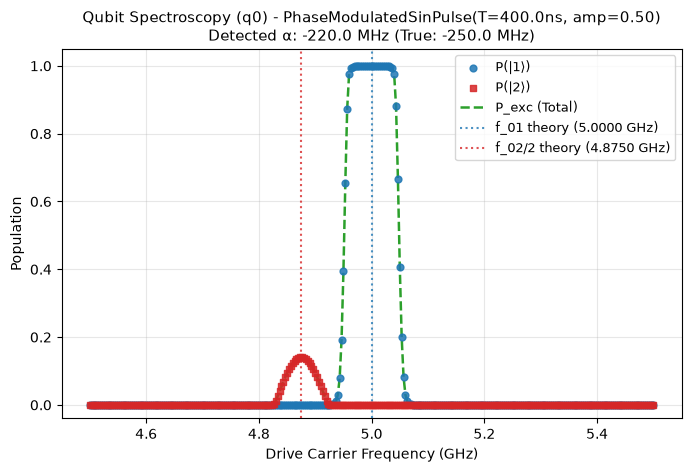

In [17]:
# 1. 初始化 Transmon（默认 levels=4, f_q=5 GHz, alpha=-250 MHz）
q = Transmon("q0", f_q=5.0e9, alpha=-250.0e6, omega_d=2*np.pi*50e6)

# 2. 方式 A：自定义相位调制脉冲进行绝热扫频 (Rapid Adiabatic Passage, RAP)
# 注意：绝热通道需要足够的驱动幅度满足绝热条件 (amp=1.0 对应 Omega_peak = 2*pi*50 MHz)
# 平顶反转带宽由 mod_freq=50 MHz 决定，在 [-50 MHz, +50 MHz] 范围内实现激发态完全反转
pulse = PhaseModulatedSinPulse(duration=400e-9, amp=0.5, mod_freq=50e6, name="Phase-Modulated Sin")
res = QubitSpectroscopyExperiment.run(
    transmon=q,
    pulse=pulse,
    freq_range=(4.5e9, 5.5e9),  # 扫频范围：4.9 GHz ~ 5.1 GHz (+/- 100 MHz)
    num_points=301,
    dt=1e-9,
    fit=False,
)
# 绘图展示激发态 P(|1>) 平顶反转特性
res.plot()


In [ ]:
# 1. 初始化 Transmon（默认 levels=4, f_q=5 GHz, alpha=-250 MHz）
q = Transmon("q0", f_q=5.0e9, alpha=-250.0e6)

# 2. 方式 A：自定义脉冲对象并扫频
pulse = FlatTopPulse(duration=200e-9, amp=0.15, ramp_time=15e-9)
res = QubitSpectroscopyExperiment.run(
    transmon=q,
    pulse=pulse,
    freq_range=(4.8e9, 5.1e9),  # 自定义扫频范围
    num_points=201,
)
print(f"检测到的 f01: {res.f01 / 1e9:.4f} GHz")
if res.has_two_photon:
    print(f"双光子共振峰 f02/2: {res.f02_half / 1e9:.4f} GHz")
    print(f"测得非简谐性 α: {res.alpha_measured / 1e6:.1f} MHz")
# 绘图（包含 P(|1>), P(|2>), 总激发态 P_exc 及拟合曲线）
res.plot()

In [ ]:
# 3. 方式 B：2D 功率能谱扫描（驱动幅度 vs 频率热力图）
pwr_res = QubitSpectroscopyExperiment.power_spectroscopy(
    transmon=q,
    pulse_type=FlatTopPulse,
    duration=200e-9,
    amps=np.linspace(0.04, 0.6, 20),
    freq_range=(4.82e9, 5.08e9),
    num_points_freq=200,
)
pwr_res.plot() 

## Rabi

In [ ]:
rabi_res = RabiExperiment.amplitude_rabi(
    transmon,
    pulse_type=GaussianPulse,
    duration=20e-9,
    amps=np.linspace(0.0, 0.9, 41),
    dt=1e-10,
)
print(f"标定所得 pi 脉冲幅度:   {rabi_res.amp_pi:.5f}")
print(f"标定所得 pi/2 脉冲幅度: {rabi_res.amp_pi_half:.5f}")
fig_rabi, ax_r = plt.subplots(figsize=(7, 4.5))
rabi_res.plot(ax=ax_r)
fig_rabi.tight_layout()

## T1

In [ ]:
pi_pulse = GaussianPulse(duration=20e-9, amp=rabi_res.amp_pi)
t1_res = T1Experiment.run(
    transmon,
    pi_pulse=pi_pulse,
    delays=np.linspace(0, 40e-6, 21),
    dt=1e-9,
)
print(f"设定理论 T1: {transmon.t1:.1f} ns | 拟合实测 T1: {t1_res.t1_fit:.1f} ns")
fig_t1, ax_t = plt.subplots(figsize=(7, 4.5))
t1_res.plot(ax=ax_t)
fig_t1.tight_layout()

## T2 Ramsey

In [ ]:
pi_half_pulse = GaussianPulse(duration=20e-9, amp=rabi_res.amp_pi_half)
detuning = 1e6  # 1 MHz 人为失谐
ramsey_res = RamseyExperiment.run(
    transmon,
    pi_half_pulse=pi_half_pulse,
    detuning=detuning,
    delays=np.linspace(0, 5e-6, 101),
    dt=1e-9,
)
print(f"设定理论 T2: {transmon.t2:.1f} ns | 拟合实测 T2*: {ramsey_res.t2_star:.1f} ns")
print(f"预设失谐:   {detuning*1e3:.2f} MHz   | 拟合实测失谐: {ramsey_res.fitted_detuning*1e3:.2f} MHz")
fig_ramsey, ax_m = plt.subplots(figsize=(7, 4.5))
ramsey_res.plot(ax=ax_m)
fig_ramsey.tight_layout()